# 🌿 Crop Disease Classification
## PyTorch + RexNet-150 + Hybrid Sampling

| Feature | Detail |
|---------|--------|
| Backbone | `rexnet_150` via `timm` (ImageNet pretrained) |
| Sampling | Hybrid: oversample minority + undersample majority |
| Augmentation | ColorJitter, RandomErasing, Flips, Rotation |
| Loss | CrossEntropyLoss + label smoothing 0.1 |
| Schedule | CosineAnnealingLR (both phases) |
| Evaluation | Macro F1 + Accuracy + Confusion Matrix + GradCAM |


In [9]:
# ═══════════════════════════════════════════════════════════════
# CELL 1 — IMPORTS
# ═══════════════════════════════════════════════════════════════
import os, json, random, warnings, itertools
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import cv2
from PIL import Image
from sklearn.model_selection import train_test_split
from sklearn.utils import resample
from sklearn.metrics import classification_report, confusion_matrix

import torch
import torch.nn as nn
import torchvision.transforms as T
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
import timm
import torchmetrics
from tqdm import tqdm

warnings.filterwarnings('ignore')
SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'

def banner(title, char='═', width=60):
    print(f'\n{char * width}')
    print(f'  {title}')
    print(f'{char * width}')

banner('ENVIRONMENT')
print(f'  🖥️  Device  : {DEVICE}')
print(f'  🔥 PyTorch : {torch.__version__}')
print(f'  🧠 timm    : {timm.__version__}')
if DEVICE == 'cuda':
    print(f'  🎮 GPU     : {torch.cuda.get_device_name(0)}')
    print(f'  💾 VRAM    : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')



════════════════════════════════════════════════════════════
  ENVIRONMENT
════════════════════════════════════════════════════════════
  🖥️  Device  : cuda
  🔥 PyTorch : 2.10.0+cu128
  🧠 timm    : 1.0.25
  🎮 GPU     : Tesla T4
  💾 VRAM    : 15.6 GB


In [10]:
# ═══════════════════════════════════════════════════════════════
# CELL 2 (FIXED) — PATHS & HYPER-PARAMETERS
# ═══════════════════════════════════════════════════════════════

ROOT           = '/kaggle/input/datasets/mexwell/crop-diseases-classification/Data'
TRAIN_CSV      = f'{ROOT}/train.csv'
LABEL_MAP_PATH = f'{ROOT}/label_num_to_disease_map.json'
TRAIN_IMG_DIR  = f'{ROOT}/train_images'

# Output directory (Kaggle saves anything written to /kaggle/working)
OUTPUT_DIR     = '/kaggle/working'
SAVE_PATH      = f'{OUTPUT_DIR}/best_crop_disease_model.pth'
FINAL_PATH     = f'{OUTPUT_DIR}/crop_disease_final.pth'

IMG_SIZE        = 224
BATCH_SIZE      = 32
NUM_CLASSES     = 5
EPOCHS_PHASE1   = 15
EPOCHS_PHASE2   = 15
LR_PHASE1       = 3e-4
LR_PHASE2       = 5e-5
WEIGHT_DECAY    = 1e-4
LABEL_SMOOTHING = 0.1

# ── Load CSV ─────────────────────────────────────────────────
df = pd.read_csv(TRAIN_CSV)

# Normalise column name
if 'image_id' not in df.columns:
    df = df.rename(columns={df.columns[0]: 'image_id'})

# Ensure image_id is a string
df['image_id'] = df['image_id'].astype(str)

# ── Load label map ────────────────────────────────────────────
with open(LABEL_MAP_PATH) as f:
    raw = json.load(f)
label_map = {int(k): v for k, v in (raw.get('root', raw)).items()}

# ── FIX: Map CSV filenames to actual filenames on disk ────────
print('🗂️  Building filename mapping...')
actual_files = os.listdir(TRAIN_IMG_DIR)
print(f'   Found {len(actual_files)} images on disk')

# Create mapping from numeric ID to actual filename
# The actual files are like "478554372.jpg" (just numbers)
# The CSV has "1000015157.jpg" (different numbers)
# We need to extract the numeric part and see if it matches any actual file

def extract_numeric_id(filename):
    """Extract numeric ID from filename (remove .jpg extension)"""
    return os.path.splitext(filename)[0]

# Build mapping from the numeric ID to actual filename
id_to_filename = {}
for fname in actual_files:
    numeric_id = extract_numeric_id(fname)
    id_to_filename[numeric_id] = fname

# Now check which CSV entries have matching files
df['exists'] = False
df['actual_filename'] = None

for idx, row in df.iterrows():
    csv_id = row['image_id']
    # Remove .jpg if present to get numeric ID
    numeric_id = csv_id.replace('.jpg', '')
    if numeric_id in id_to_filename:
        df.at[idx, 'exists'] = True
        df.at[idx, 'actual_filename'] = id_to_filename[numeric_id]

# Filter to only rows with existing images
missing_count = (~df['exists']).sum()
if missing_count > 0:
    print(f'   ⚠️  {missing_count} images from CSV not found on disk, filtering out...')
    df = df[df['exists']].reset_index(drop=True)
    print(f'   ✅ Remaining samples: {len(df):,}')
else:
    print(f'   ✅ All {len(df):,} images found on disk!')

# Update the image_id column to use actual filenames
df['image_id'] = df['actual_filename']

banner('CONFIGURATION')
print(f'  📁 Root dir      : {ROOT}')
print(f'  📄 CSV rows      : {len(df):,}')
print(f'  🔑 Columns       : {df.columns.tolist()}')
print(f'  🖼️  Sample id     : {df["image_id"].iloc[0]}')
print()

# Verify images exist
missing = []
for fname in df['image_id'].head(10):
    full = os.path.join(TRAIN_IMG_DIR, fname)
    if not os.path.exists(full):
        missing.append(fname)

if missing:
    print(f'  ⚠️  WARNING: {len(missing)} of 10 sample files NOT found on disk!')
    print(f'     First missing : {missing[0]}')
else:
    print(f'  ✅ Path check passed — images confirmed on disk')

print()
banner('LABEL MAP')
for k, v in sorted(label_map.items()):
    print(f'  [{k}]  {v}')

🗂️  Building filename mapping...
   Found 17938 images on disk
   ⚠️  3459 images from CSV not found on disk, filtering out...
   ✅ Remaining samples: 17,938

════════════════════════════════════════════════════════════
  CONFIGURATION
════════════════════════════════════════════════════════════
  📁 Root dir      : /kaggle/input/datasets/mexwell/crop-diseases-classification/Data
  📄 CSV rows      : 17,938
  🔑 Columns       : ['image_id', 'label', 'exists', 'actual_filename']
  🖼️  Sample id     : 157078263.jpg

  ✅ Path check passed — images confirmed on disk


════════════════════════════════════════════════════════════
  LABEL MAP
════════════════════════════════════════════════════════════
  [0]  Cassava Bacterial Blight (CBB)
  [1]  Cassava Brown Streak Disease (CBSD)
  [2]  Cassava Green Mottle (CGM)
  [3]  Cassava Mosaic Disease (CMD)
  [4]  Healthy



════════════════════════════════════════════════════════════
  CLASS DISTRIBUTION (ORIGINAL)
════════════════════════════════════════════════════════════
  [0] Cassava Bacterial Blight (CBB)           ██                                 921  (5.1%)
  [1] Cassava Brown Streak Disease (CBSD)      ████                              1831  (10.2%)
  [2] Cassava Green Mottle (CGM)               █████                             1993  (11.1%)
  [3] Cassava Mosaic Disease (CMD)             ██████████████████████████████   11027  (61.5%)
  [4] Healthy                                  █████                             2166  (12.1%)

  Total images     : 17,938
  Imbalance ratio  : 12.0x  (max/min class)
  Most common      : Cassava Mosaic Disease (CMD) (11,027)
  Least common     : Cassava Bacterial Blight (CBB) (921)


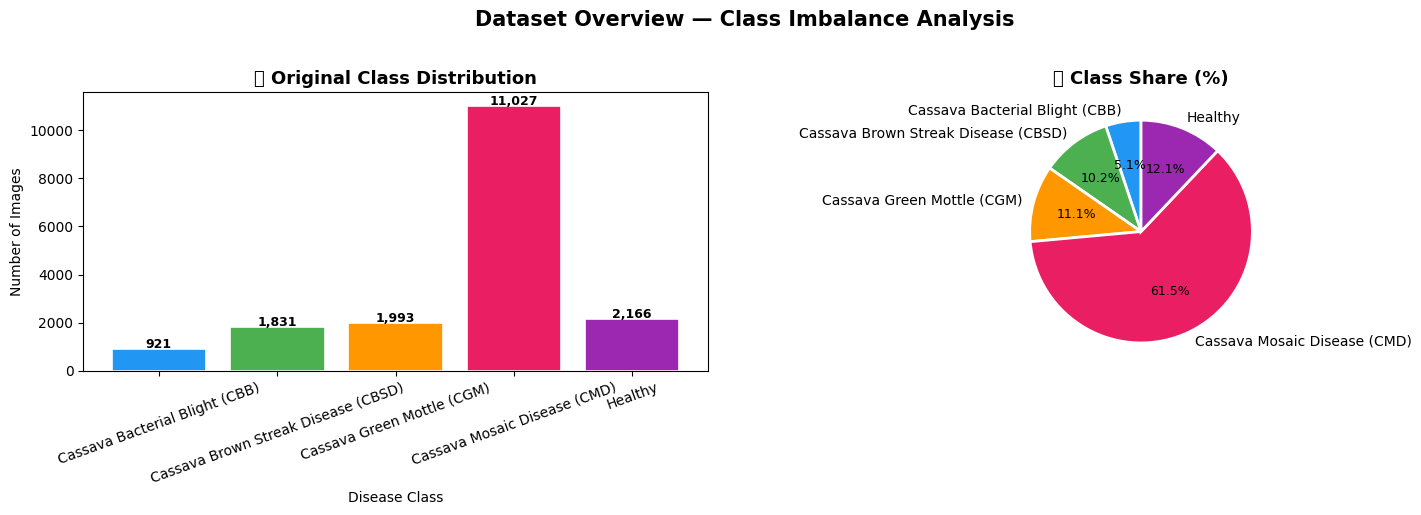

In [11]:
# ═══════════════════════════════════════════════════════════════
# CELL 3 — EXPLORATORY DATA ANALYSIS
# ═══════════════════════════════════════════════════════════════

class_counts = df['label'].value_counts().sort_index()
COLORS = ['#2196F3','#4CAF50','#FF9800','#E91E63','#9C27B0']

banner('CLASS DISTRIBUTION (ORIGINAL)')
max_count = class_counts.max()
min_count = class_counts.min()
imbalance_ratio = max_count / min_count

for cls_id, count in class_counts.items():
    bar  = '█' * int(count / max_count * 30)
    name = label_map[cls_id]
    pct  = count / len(df) * 100
    print(f'  [{cls_id}] {name:<40s} {bar:<32s} {count:5d}  ({pct:.1f}%)')

print(f'\n  Total images     : {len(df):,}')
print(f'  Imbalance ratio  : {imbalance_ratio:.1f}x  (max/min class)')
print(f'  Most common      : {label_map[class_counts.idxmax()]} ({max_count:,})')
print(f'  Least common     : {label_map[class_counts.idxmin()]} ({min_count:,})')

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
bars = axes[0].bar([label_map[i] for i in class_counts.index],
                   class_counts.values, color=COLORS, edgecolor='white', linewidth=1.2)
axes[0].set_title('📊 Original Class Distribution', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Disease Class'); axes[0].set_ylabel('Number of Images')
axes[0].tick_params(axis='x', rotation=20)
for bar, val in zip(bars, class_counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 30,
                 f'{val:,}', ha='center', fontsize=9, fontweight='bold')

wedges, texts, autotexts = axes[1].pie(
    class_counts.values,
    labels=[label_map[i] for i in class_counts.index],
    autopct='%1.1f%%', colors=COLORS, startangle=90,
    wedgeprops=dict(edgecolor='white', linewidth=2))
for at in autotexts: at.set_fontsize(9)
axes[1].set_title('🥧 Class Share (%)', fontsize=13, fontweight='bold')

plt.suptitle('Dataset Overview — Class Imbalance Analysis', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout(); plt.show()



════════════════════════════════════════════════════════════
  HYBRID SAMPLING REPORT
════════════════════════════════════════════════════════════
  Strategy     : auto (target = median class size)
  Target/class : 1,993 samples

  Class Disease                                 Before   After  Action
  ----------------------------------------------------------------------
  [0]  Cassava Bacterial Blight (CBB)             921 →   1,993  ⬆️  oversampled
  [1]  Cassava Brown Streak Disease (CBSD)      1,831 →   1,993  ⬆️  oversampled
  [2]  Cassava Green Mottle (CGM)               1,993 →   1,993  ✅ unchanged
  [3]  Cassava Mosaic Disease (CMD)            11,027 →   1,993  ⬇️  undersampled
  [4]  Healthy                                  2,166 →   1,993  ⬇️  undersampled

  Original  total :  17,938
  Balanced  total :   9,965


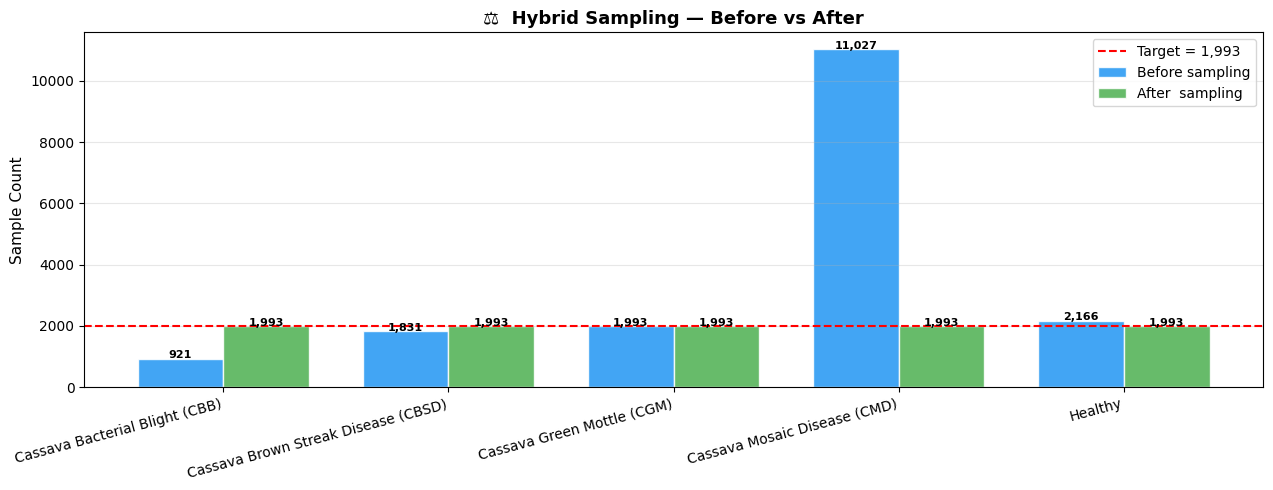

In [12]:
# ═══════════════════════════════════════════════════════════════
# CELL 4 — HYBRID SAMPLING
# ═══════════════════════════════════════════════════════════════

def hybrid_sampling(df, target_samples=None, strategy='auto', random_state=42):
    counts = df['label'].value_counts()
    if target_samples is None:
        target_samples = int(counts.median() if strategy == 'auto' else counts.mean())

    parts = []
    ops   = {'oversampled': 0, 'undersampled': 0, 'unchanged': 0}

    for cls in sorted(df['label'].unique()):
        cls_df = df[df['label'] == cls]
        n      = len(cls_df)
        if n < target_samples:
            cls_df = resample(cls_df, replace=True,
                              n_samples=target_samples, random_state=random_state)
            tag = 'oversampled'
        elif n > target_samples:
            cls_df = resample(cls_df, replace=False,
                              n_samples=target_samples, random_state=random_state)
            tag = 'undersampled'
        else:
            tag = 'unchanged'
        ops[tag] += 1
        parts.append((cls, n, len(cls_df), tag, cls_df))

    balanced = (pd.concat([p[4] for p in parts], ignore_index=True)
                  .sample(frac=1, random_state=random_state)
                  .reset_index(drop=True))
    return balanced, parts, target_samples, ops


balanced_df, sampling_log, target, ops = hybrid_sampling(df, strategy='auto')

banner('HYBRID SAMPLING REPORT')
print(f'  Strategy     : auto (target = median class size)')
print(f'  Target/class : {target:,} samples')
print()
print('  {:<5} {:<38} {:>7} {:>7}  Action'.format('Class','Disease','Before','After'))
print('  ' + '-'*70)
for cls, before, after, tag, _ in sampling_log:
    emoji = '⬆️ ' if tag == 'oversampled' else ('⬇️ ' if tag == 'undersampled' else '✅')
    arrow = f'{before:>7,} → {after:>7,}'
    print(f'  [{cls}]  {label_map[cls]:<38} {arrow}  {emoji} {tag}')

print()
print(f'  Original  total : {len(df):>7,}')
print(f'  Balanced  total : {len(balanced_df):>7,}')

bal_counts = balanced_df['label'].value_counts().sort_index()
names = [label_map[i] for i in range(NUM_CLASSES)]
fig, ax = plt.subplots(figsize=(13, 5))
x = np.arange(NUM_CLASSES); w = 0.38
b1 = ax.bar(x - w/2, class_counts.values, w, label='Before sampling',
            color='#2196F3', alpha=0.85, edgecolor='white')
b2 = ax.bar(x + w/2, bal_counts.values,   w, label='After  sampling',
            color='#4CAF50', alpha=0.85, edgecolor='white')
ax.axhline(target, color='red', linestyle='--', linewidth=1.5, label=f'Target = {target:,}')
ax.set_xticks(x); ax.set_xticklabels(names, rotation=15, ha='right')
ax.set_ylabel('Sample Count', fontsize=11)
ax.set_title('⚖️  Hybrid Sampling — Before vs After', fontsize=13, fontweight='bold')
ax.legend(); ax.grid(axis='y', alpha=0.3)
for bar in list(b1) + list(b2):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 20,
            f'{int(bar.get_height()):,}', ha='center', fontsize=8, fontweight='bold')
plt.tight_layout(); plt.show()


In [13]:
# ═══════════════════════════════════════════════════════════════
# CELL 5 — TRAIN / VALIDATION SPLIT
# ═══════════════════════════════════════════════════════════════

train_df, val_df = train_test_split(
    balanced_df,
    test_size=0.15,
    stratify=balanced_df['label'],
    random_state=SEED
)
train_df = train_df.reset_index(drop=True)
val_df   = val_df.reset_index(drop=True)

banner('TRAIN / VALIDATION SPLIT')
total = len(train_df) + len(val_df)
print(f'  Total balanced  : {total:,}')
print(f'  Train set       : {len(train_df):,}  ({len(train_df)/total*100:.0f}%)')
print(f'  Validation set  : {len(val_df):,}  ({len(val_df)/total*100:.0f}%)')
print()
print('  {:<5} {:<38} {:>7}  {:>7}'.format('Cls','Disease','Train','Val'))
print('  ' + '-'*60)
tr_dist = train_df['label'].value_counts().sort_index()
vl_dist = val_df['label'].value_counts().sort_index()
for i in range(NUM_CLASSES):
    print(f'  [{i}]  {label_map[i]:<38} {tr_dist[i]:>7,}  {vl_dist[i]:>7,}')



════════════════════════════════════════════════════════════
  TRAIN / VALIDATION SPLIT
════════════════════════════════════════════════════════════
  Total balanced  : 9,965
  Train set       : 8,470  (85%)
  Validation set  : 1,495  (15%)

  Cls   Disease                                  Train      Val
  ------------------------------------------------------------
  [0]  Cassava Bacterial Blight (CBB)           1,694      299
  [1]  Cassava Brown Streak Disease (CBSD)      1,694      299
  [2]  Cassava Green Mottle (CGM)               1,694      299
  [3]  Cassava Mosaic Disease (CMD)             1,694      299
  [4]  Healthy                                  1,694      299


In [14]:
# ═══════════════════════════════════════════════════════════════
# CELL 6 (FIXED) — DATASET, TRANSFORMS & DATALOADERS
# ═══════════════════════════════════════════════════════════════

MEAN = [0.485, 0.456, 0.406]
STD  = [0.229, 0.224, 0.225]

train_transforms = T.Compose([
    T.Resize((IMG_SIZE + 32, IMG_SIZE + 32)),
    T.RandomCrop(IMG_SIZE),
    T.RandomHorizontalFlip(),
    T.RandomVerticalFlip(),
    T.RandomRotation(30),
    T.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.3, hue=0.1),
    T.RandomGrayscale(p=0.05),
    T.ToTensor(),
    T.Normalize(mean=MEAN, std=STD),
    T.RandomErasing(p=0.25, scale=(0.02, 0.1)),
])

val_transforms = T.Compose([
    T.Resize((IMG_SIZE, IMG_SIZE)),
    T.ToTensor(),
    T.Normalize(mean=MEAN, std=STD),
])

class CropDiseaseDataset(Dataset):
    """Loads crop disease images from a DataFrame."""
    
    def __init__(self, dataframe, img_dir, transforms=None):
        self.df = dataframe.reset_index(drop=True)
        self.img_dir = img_dir
        self.transforms = transforms

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        fname = str(row['image_id'])
        img_path = os.path.join(self.img_dir, fname)
        
        if not os.path.exists(img_path):
            raise FileNotFoundError(f"Image not found: {img_path}")
            
        img = Image.open(img_path).convert('RGB')
        if self.transforms:
            img = self.transforms(img)
        return img, int(row['label'])

def make_weighted_sampler(dataset):
    """WeightedRandomSampler — every mini-batch is class-balanced."""
    labels = [int(dataset.df.iloc[i]['label']) for i in range(len(dataset))]
    counts = np.bincount(labels)
    weights = 1.0 / counts[labels]
    return WeightedRandomSampler(
        weights=torch.DoubleTensor(weights),
        num_samples=len(weights),
        replacement=True
    )

train_ds = CropDiseaseDataset(train_df, TRAIN_IMG_DIR, train_transforms)
val_ds = CropDiseaseDataset(val_df, TRAIN_IMG_DIR, val_transforms)
sampler = make_weighted_sampler(train_ds)

train_dl = DataLoader(train_ds, batch_size=BATCH_SIZE,
                      sampler=sampler, num_workers=4, pin_memory=True)
val_dl = DataLoader(val_ds, batch_size=BATCH_SIZE,
                    shuffle=False, num_workers=4, pin_memory=True)

banner('DATALOADERS READY')
print(f'  Train dataset   : {len(train_ds):,} images  →  {len(train_dl):,} batches')
print(f'  Val   dataset   : {len(val_ds):,}  images  →  {len(val_dl):,}  batches')
print(f'  Batch size      : {BATCH_SIZE}')
print(f'  Sampler         : WeightedRandomSampler (balanced batches)')


════════════════════════════════════════════════════════════
  DATALOADERS READY
════════════════════════════════════════════════════════════
  Train dataset   : 8,470 images  →  265 batches
  Val   dataset   : 1,495  images  →  47  batches
  Batch size      : 32
  Sampler         : WeightedRandomSampler (balanced batches)


📷  Loading one batch from the training dataloader...
   Batch shape : (32, 3, 224, 224)  (B x C x H x W)
   Labels seen : [0, 1, 2, 3, 4]


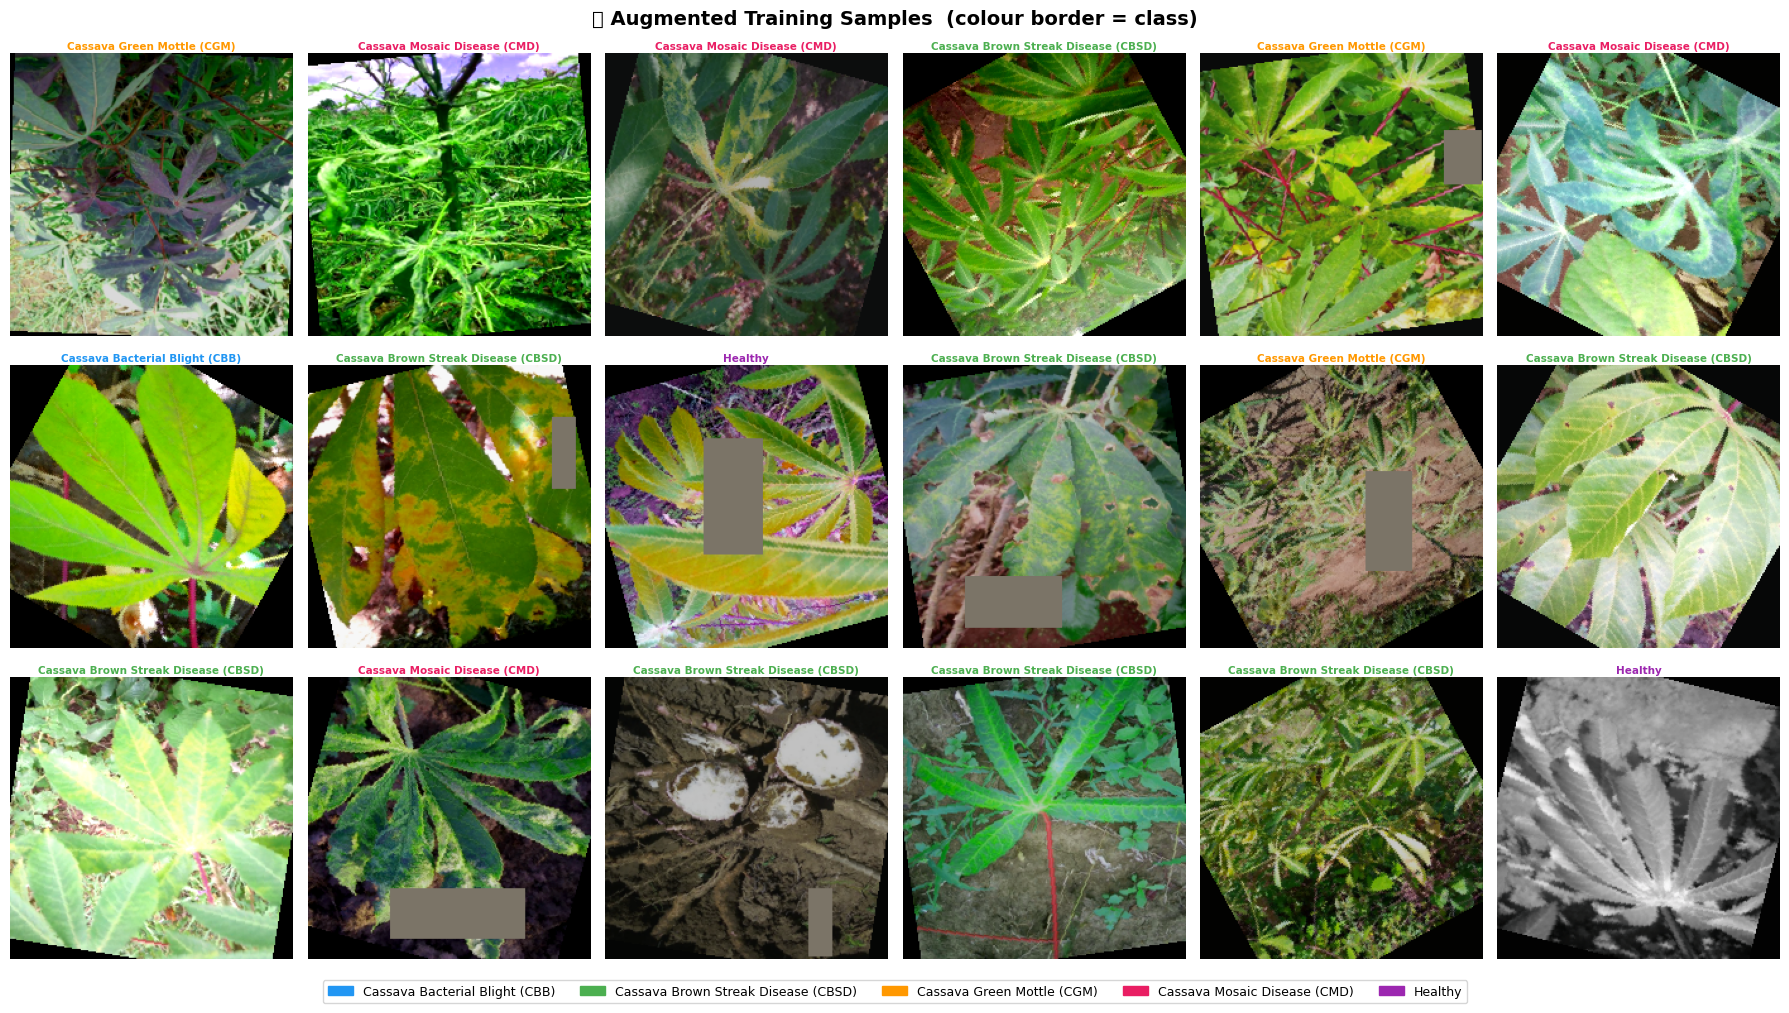

In [15]:
# ═══════════════════════════════════════════════════════════════
# CELL 7 — VISUALISE AUGMENTED TRAINING SAMPLES
# ═══════════════════════════════════════════════════════════════

def denorm(t):
    """Reverse ImageNet normalisation for display."""
    inv = T.Compose([
        T.Normalize(mean=[0., 0., 0.], std=[1/s for s in STD]),
        T.Normalize(mean=[-m for m in MEAN], std=[1., 1., 1.])
    ])
    return (inv(t.cpu()).clamp(0, 1).permute(1, 2, 0).numpy() * 255).astype(np.uint8)


print('📷  Loading one batch from the training dataloader...')
imgs, labels = next(iter(train_dl))
print(f'   Batch shape : {tuple(imgs.shape)}  (B x C x H x W)')
print(f'   Labels seen : {sorted(set(labels.tolist()))}')

n_show = min(18, len(imgs))
fig, axes = plt.subplots(3, 6, figsize=(18, 10))
for i, ax in enumerate(axes.ravel()):
    if i >= n_show:
        ax.axis('off')
        continue
    img_np = denorm(imgs[i])
    cls_id = labels[i].item()
    ax.imshow(img_np)
    ax.set_title(label_map[cls_id], fontsize=7.5, fontweight='bold',
                 color=COLORS[cls_id], pad=3)
    ax.axis('off')
    for spine in ax.spines.values():
        spine.set_edgecolor(COLORS[cls_id])
        spine.set_linewidth(2)
        spine.set_visible(True)

plt.suptitle('🌿 Augmented Training Samples  (colour border = class)',
             fontsize=14, fontweight='bold')
patches = [mpatches.Patch(color=COLORS[i], label=label_map[i]) for i in range(NUM_CLASSES)]
fig.legend(handles=patches, loc='lower center', ncol=5,
           fontsize=9, frameon=True, bbox_to_anchor=(0.5, -0.02))
plt.tight_layout(); plt.show()


In [16]:
# ═══════════════════════════════════════════════════════════════
# CELL 8 — MODEL  (rexnet_150 via timm)
# ═══════════════════════════════════════════════════════════════

model = timm.create_model('rexnet_150', pretrained=True, num_classes=NUM_CLASSES)
model = model.to(DEVICE)


def freeze_backbone(model):
    for name, param in model.named_parameters():
        param.requires_grad = ('head' in name)
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    total     = sum(p.numel() for p in model.parameters())
    banner('PHASE 1 — FROZEN BACKBONE')
    print(f'  Trainable params : {trainable:>10,}  (head only)')
    print(f'  Frozen    params : {total - trainable:>10,}  (backbone)')
    print(f'  Total     params : {total:>10,}')


def unfreeze_top(model, n_blocks=3):
    for param in model.parameters():
        param.requires_grad = False
    blocks = list(model.features.children())
    for block in blocks[-n_blocks:]:
        for param in block.parameters():
            param.requires_grad = True
    for param in model.head.parameters():
        param.requires_grad = True
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    total     = sum(p.numel() for p in model.parameters())
    banner('PHASE 2 — TOP LAYERS UNFROZEN')
    print(f'  Unfrozen blocks  : last {n_blocks} feature blocks + head')
    print(f'  Trainable params : {trainable:>10,}')
    print(f'  Frozen    params : {total - trainable:>10,}')
    print(f'  Total     params : {total:>10,}')


freeze_backbone(model)
print()
print('  Backbone : rexnet_150 (pretrained on ImageNet)')
print('  Head     : Linear(1280 → 5)')
print('  Strategy : Phase 1 train head → Phase 2 fine-tune top blocks')


model.safetensors:   0%|          | 0.00/39.2M [00:00<?, ?B/s]


════════════════════════════════════════════════════════════
  PHASE 1 — FROZEN BACKBONE
════════════════════════════════════════════════════════════
  Trainable params :      9,605  (head only)
  Frozen    params :  7,807,593  (backbone)
  Total     params :  7,817,198

  Backbone : rexnet_150 (pretrained on ImageNet)
  Head     : Linear(1280 → 5)
  Strategy : Phase 1 train head → Phase 2 fine-tune top blocks


In [17]:
# ═══════════════════════════════════════════════════════════════
# CELL 9 — TRAINING HELPERS
# ═══════════════════════════════════════════════════════════════

f1_metric = torchmetrics.F1Score(
    task='multiclass', num_classes=NUM_CLASSES, average='macro'
).to(DEVICE)


def run_epoch(model, loader, loss_fn, optimizer=None, phase='train'):
    is_train = (phase == 'train')
    model.train() if is_train else model.eval()
    f1_metric.reset()
    total_loss, correct, total = 0.0, 0, 0

    ctx = torch.enable_grad() if is_train else torch.no_grad()
    with ctx:
        for imgs, gts in tqdm(loader, desc=f'{phase:5s}', leave=False):
            imgs, gts = imgs.to(DEVICE), gts.to(DEVICE)
            preds = model(imgs)
            loss  = loss_fn(preds, gts)
            if is_train:
                optimizer.zero_grad(); loss.backward(); optimizer.step()
            total_loss += loss.item()
            correct    += (preds.argmax(1) == gts).sum().item()
            total      += gts.size(0)
            f1_metric.update(preds, gts)

    return total_loss / len(loader), correct / total, f1_metric.compute().item()


def train_phase(model, train_dl, val_dl, loss_fn, optimizer, scheduler,
                epochs, phase_name, best_f1, history, save_path):
    header = '  {:>4}  {:>8}  {:>7}  {:>7}  {:>8}  {:>7}  {:>7}  {:>8}'.format(
               'Ep','Tr Loss','Tr Acc','Tr F1','Vl Loss','Vl Acc','Vl F1','Saved?')
    print(header)
    print('  ' + '─' * (len(header) - 2))

    for epoch in range(1, epochs + 1):
        tr_loss, tr_acc, tr_f1 = run_epoch(model, train_dl, loss_fn, optimizer, 'train')
        vl_loss, vl_acc, vl_f1 = run_epoch(model, val_dl,   loss_fn, phase='val')
        if scheduler: scheduler.step()

        history['tr_loss'].append(tr_loss);  history['vl_loss'].append(vl_loss)
        history['tr_acc'].append(tr_acc);    history['vl_acc'].append(vl_acc)
        history['tr_f1'].append(tr_f1);      history['vl_f1'].append(vl_f1)

        saved = ''
        if vl_f1 > best_f1:
            best_f1 = vl_f1
            torch.save(model.state_dict(), save_path)
            saved = '💾 BEST'

        print(f'  {epoch:>4}  {tr_loss:>8.4f}  {tr_acc:>7.4f}  {tr_f1:>7.4f}  '
              f'{vl_loss:>8.4f}  {vl_acc:>7.4f}  {vl_f1:>7.4f}  {saved}')

    return best_f1

print('✅  Training helpers defined')


✅  Training helpers defined


In [ ]:
# ═══════════════════════════════════════════════════════════════
# CELL 10 — PHASE 1: TRAIN HEAD (FROZEN BACKBONE)
# ═══════════════════════════════════════════════════════════════

loss_fn   = nn.CrossEntropyLoss(label_smoothing=LABEL_SMOOTHING)
optimizer = torch.optim.Adam(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=LR_PHASE1, weight_decay=WEIGHT_DECAY
)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer, T_max=EPOCHS_PHASE1, eta_min=1e-6
)

history = {'tr_loss':[], 'vl_loss':[], 'tr_acc':[], 'vl_acc':[], 'tr_f1':[], 'vl_f1':[]}
best_f1 = 0.0

banner('PHASE 1 — TRAIN HEAD ONLY  (backbone frozen)')
print(f'  Epochs     : {EPOCHS_PHASE1}')
print(f'  LR         : {LR_PHASE1}')
print(f'  Loss       : CrossEntropy + label_smoothing={LABEL_SMOOTHING}')
print(f'  Scheduler  : CosineAnnealingLR')
print(f'  Save path  : {SAVE_PATH}')
print()

best_f1 = train_phase(
    model, train_dl, val_dl, loss_fn, optimizer, scheduler,
    EPOCHS_PHASE1, 'Phase 1', best_f1, history, SAVE_PATH
)
p1_end = len(history['tr_loss'])
print(f'\n  ✅ Phase 1 complete  |  Best val F1 so far: {best_f1:.4f}')



════════════════════════════════════════════════════════════
  PHASE 1 — TRAIN HEAD ONLY  (backbone frozen)
════════════════════════════════════════════════════════════
  Epochs     : 15
  LR         : 0.0003
  Loss       : CrossEntropy + label_smoothing=0.1
  Scheduler  : CosineAnnealingLR
  Save path  : /kaggle/working/best_crop_disease_model.pth

    Ep   Tr Loss   Tr Acc    Tr F1   Vl Loss   Vl Acc    Vl F1    Saved?
  ──────────────────────────────────────────────────────────────────────


     1    3.2433   0.2541   0.2529    2.5831   0.2803   0.2786  💾 BEST


train:  46%|████▌     | 121/265 [00:24<00:30,  4.78it/s]

In [ ]:
# ═══════════════════════════════════════════════════════════════
# CELL 11 — PHASE 2: FINE-TUNE TOP BLOCKS
# ═══════════════════════════════════════════════════════════════

unfreeze_top(model, n_blocks=3)

optimizer2 = torch.optim.Adam(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=LR_PHASE2, weight_decay=WEIGHT_DECAY
)
scheduler2 = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer2, T_max=EPOCHS_PHASE2, eta_min=1e-7
)

print(f'  Epochs     : {EPOCHS_PHASE2}')
print(f'  LR         : {LR_PHASE2}  (10× smaller than Phase 1)')
print(f'  Strategy   : last 3 feature blocks + head are trainable')
print()

best_f1 = train_phase(
    model, train_dl, val_dl, loss_fn, optimizer2, scheduler2,
    EPOCHS_PHASE2, 'Phase 2', best_f1, history, SAVE_PATH
)
print(f'\n  ✅ Phase 2 complete  |  Best val F1 overall: {best_f1:.4f}')


In [ ]:
# ═══════════════════════════════════════════════════════════════
# CELL 12 — LEARNING CURVES
# ═══════════════════════════════════════════════════════════════

banner('TRAINING HISTORY SUMMARY')
print(f'  Total epochs trained : {len(history["tr_loss"])}')
print(f'  Best val F1 (macro)  : {best_f1:.4f}')
print(f'  Best val Accuracy    : {max(history["vl_acc"]):.4f}')
print(f'  Best val Loss        : {min(history["vl_loss"]):.4f}')

epochs_x = range(1, len(history['tr_loss']) + 1)
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

plot_cfg = [
    ('tr_loss', 'vl_loss', '📉 Loss',     'Loss'),
    ('tr_acc',  'vl_acc',  '🎯 Accuracy', 'Accuracy'),
    ('tr_f1',   'vl_f1',   '📊 Macro F1', 'F1 Score'),
]
for ax, (tr_k, vl_k, title, ylabel) in zip(axes, plot_cfg):
    ax.plot(epochs_x, history[tr_k], label='Train',      color='#2196F3', marker='o', ms=3)
    ax.plot(epochs_x, history[vl_k], label='Validation', color='#FF9800', marker='s', ms=3)
    ax.axvline(x=p1_end + 0.5, color='red', linestyle='--',
               linewidth=1.5, label=f'Fine-tuning starts (ep {p1_end+1})')
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_xlabel('Epoch'); ax.set_ylabel(ylabel)
    ax.legend(fontsize=9); ax.grid(alpha=0.3)
    ax.fill_between(epochs_x, history[tr_k], history[vl_k], alpha=0.08, color='grey')

plt.suptitle('Training History — Phase 1 (frozen) + Phase 2 (fine-tune)',
             fontsize=14, fontweight='bold')
plt.tight_layout(); plt.show()


In [ ]:
# ═══════════════════════════════════════════════════════════════
# CELL 13 — EVALUATION: CLASSIFICATION REPORT + CONFUSION MATRIX
# ═══════════════════════════════════════════════════════════════

model.load_state_dict(torch.load(SAVE_PATH, map_location=DEVICE))
model.eval()

all_preds, all_labels = [], []
with torch.no_grad():
    for imgs, gts in tqdm(val_dl, desc='🔍 Evaluating'):
        preds = model(imgs.to(DEVICE)).argmax(1).cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(gts.numpy())

class_names = [label_map[i] for i in range(NUM_CLASSES)]

banner('CLASSIFICATION REPORT')
print(classification_report(all_labels, all_preds, target_names=class_names))

def plot_cm(cm_data, classes, normalize=False, title='Confusion Matrix'):
    if normalize:
        cm_data = cm_data.astype(float) / cm_data.sum(axis=1, keepdims=True)
    fig, ax = plt.subplots(figsize=(9, 7))
    im = ax.imshow(cm_data, cmap='Blues')
    plt.colorbar(im, ax=ax)
    ax.set_title(title, fontsize=14, fontweight='bold', pad=12)
    ticks = np.arange(len(classes))
    ax.set_xticks(ticks); ax.set_xticklabels(classes, rotation=30, ha='right', fontsize=9)
    ax.set_yticks(ticks); ax.set_yticklabels(classes, fontsize=9)
    fmt = '.2f' if normalize else 'd'
    thresh = cm_data.max() / 2
    for i, j in itertools.product(range(cm_data.shape[0]), range(cm_data.shape[1])):
        ax.text(j, i, format(cm_data[i, j], fmt), ha='center', va='center', fontsize=10,
                color='white' if cm_data[i, j] > thresh else 'black')
    ax.set_ylabel('True Label', fontweight='bold')
    ax.set_xlabel('Predicted Label', fontweight='bold')
    plt.tight_layout(); plt.show()

cm = confusion_matrix(all_labels, all_preds)
plot_cm(cm, class_names, title='🔢 Confusion Matrix (raw counts)')
plot_cm(cm, class_names, normalize=True, title='📊 Confusion Matrix (normalised %)')


In [ ]:
# ═══════════════════════════════════════════════════════════════
# CELL 14 — GRADCAM VISUALISATION
# ═══════════════════════════════════════════════════════════════

class SaveFeatures:
    features = None
    def __init__(self, module):
        self.hook = module.register_forward_hook(self._hook)
    def _hook(self, _, __, output):
        self.features = output.detach().cpu().numpy()
    def remove(self):
        self.hook.remove()


def get_cam(conv_features, fc_weights, class_idx):
    _, C, H, W = conv_features.shape
    cam = fc_weights[class_idx].dot(conv_features[0].reshape(C, H * W)).reshape(H, W)
    cam = (cam - cam.min()) / (cam.max() - cam.min() + 1e-8)
    return cam


final_conv  = model.features[-1]
fc_weights  = list(model.head.fc.parameters())[0].detach().cpu().numpy()
activations = SaveFeatures(final_conv)

# num_workers=0 for GradCAM to avoid multiprocessing hook issues
vis_dl = DataLoader(val_ds, batch_size=1, shuffle=True,
                    num_workers=0, pin_memory=False)

num_vis = 12
fig, axes = plt.subplots(3, 4, figsize=(20, 16))
axes = axes.ravel()

correct_count, wrong_count = 0, 0
model.eval()
print('🔥 Generating GradCAM visualisations...')

for ax_idx, (img_t, gt) in enumerate(vis_dl):
    if ax_idx >= num_vis:
        break
    with torch.no_grad():
        out = model(img_t.to(DEVICE))
    pred = out.argmax(1).item()
    conf = torch.softmax(out, 1).max().item()
    cam  = get_cam(activations.features, fc_weights, pred)

    raw     = denorm(img_t[0])
    heatmap = cv2.resize(cam, (IMG_SIZE, IMG_SIZE))

    axes[ax_idx].imshow(raw)
    axes[ax_idx].imshow(heatmap, alpha=0.45, cmap='jet')

    is_correct = (pred == gt.item())
    color = 'limegreen' if is_correct else 'red'
    icon  = '✅' if is_correct else '❌'
    if is_correct: correct_count += 1
    else: wrong_count += 1

    axes[ax_idx].set_title(
        f'{icon} GT : {label_map[gt.item()]}\n'
        f'    Pred: {label_map[pred]}  ({conf*100:.1f}%)',
        fontsize=7.5, color=color, fontweight='bold'
    )
    axes[ax_idx].axis('off')

activations.remove()
plt.suptitle('🔥 GradCAM — What is the model looking at?\n(green = correct, red = wrong)',
             fontsize=14, fontweight='bold')
plt.tight_layout(); plt.show()
print(f'  Shown {num_vis} samples: {correct_count} correct ✅  |  {wrong_count} wrong ❌')


In [ ]:
# ═══════════════════════════════════════════════════════════════
# CELL 15 — SAVE MODEL & FINAL SUMMARY
# ═══════════════════════════════════════════════════════════════

# Save the final state dict to Kaggle output (/kaggle/working)
torch.save(model.state_dict(), FINAL_PATH)
print(f'✅ Final model saved  → {FINAL_PATH}')
print(f'✅ Best model saved   → {SAVE_PATH}')
print()

# Verify files exist in output
for p in [SAVE_PATH, FINAL_PATH]:
    size_mb = os.path.getsize(p) / 1e6
    print(f'   📦 {os.path.basename(p)}  ({size_mb:.1f} MB)  →  {p}')

# Recompute final F1 from best checkpoint
model.load_state_dict(torch.load(SAVE_PATH, map_location=DEVICE))
model.eval()
f1_metric.reset()
with torch.no_grad():
    for imgs, gts in val_dl:
        f1_metric.update(model(imgs.to(DEVICE)), gts.to(DEVICE))
final_f1  = f1_metric.compute().item()
final_acc = max(history['vl_acc'])

banner('🌿 FINAL SUMMARY  —  CROP DISEASE CLASSIFIER', char='═', width=62)
print()
print('  📁  DATASET')
print(f'    Original size   : {len(df):>8,} images')
print(f'    Balanced size   : {len(balanced_df):>8,} images  (hybrid sampling)')
print(f'    Train set       : {len(train_df):>8,} images  (85%)')
print(f'    Validation set  : {len(val_df):>8,} images  (15%)')
print()
print('  🧠  MODEL')
print(f'    Architecture    : rexnet_150  (timm pretrained)')
print(f'    Phase 1 epochs  : {EPOCHS_PHASE1}  (head only)')
print(f'    Phase 2 epochs  : {EPOCHS_PHASE2}  (top 3 blocks + head)')
print(f'    Best checkpoint : {SAVE_PATH}')
print(f'    Final model     : {FINAL_PATH}')
print()
print('  📊  RESULTS')
print(f'    Best val F1 (macro) : {best_f1:.4f}   ({best_f1*100:.2f}%)')
print(f'    Best val Accuracy   : {final_acc:.4f}   ({final_acc*100:.2f}%)')
print(f'    Best val Loss       : {min(history["vl_loss"]):.4f}')
print()
print('  ═' * 31)
print(f'  🏆  FINAL  VAL  F1  =  {best_f1:.4f}  ({best_f1*100:.2f}%)')
print('  ═' * 31)
print()
print('  💡 Both .pth files are in /kaggle/working and will appear')
print('     in the Kaggle notebook Output tab automatically.')
